<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding How The Data Is Distributed**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform Exploratory Data Analysis (EDA). You will examine the structure of the data, visualize key variables, and analyze trends related to developer experience, tools, job satisfaction, and other important aspects.


## Objectives


In this lab you will perform the following:


- Understand the structure of the dataset.

- Perform summary statistics and data visualization.

- Identify trends in developer experience, tools, job satisfaction, and other key variables.


### Install the required libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn


### Step 1: Import Libraries and Load Data


- Import the `pandas`, `matplotlib.pyplot`, and `seaborn` libraries.


- You will begin with loading the dataset. You can use the pyfetch method if working on JupyterLite. Otherwise, you can use pandas' read_csv() function directly on their local machines or cloud environments.


In [2]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Stack Overflow survey dataset
data_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv'
df = pd.read_csv(data_url)

# Display the first few rows of the dataset
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Step 2: Examine the Structure of the Data


- Display the column names, data types, and summary information to understand the data structure.

- Objective: Gain insights into the dataset's shape and available variables.


In [3]:
## Write your code here
# 1. Display the dataset's shape (number of rows and columns)
print("Dataset Shape (Rows, Columns):")
print(df.shape)
print("-" * 30)

# 2. Display column names, data types, and non-null counts
print("\nDataset Information:")
df.info()
print("-" * 30)

# 3. Display summary statistics for numerical variables
print("\nSummary Statistics:")
print(df.describe())

Dataset Shape (Rows, Columns):
(65437, 114)
------------------------------

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 65437 entries, 0 to 65436
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), str(100)
memory usage: 56.9 MB
------------------------------

Summary Statistics:
         ResponseId      CompTotal       WorkExp  JobSatPoints_1  \
count  65437.000000   3.374000e+04  29658.000000    29324.000000   
mean   32719.000000  2.963841e+145     11.466957       18.581094   
std    18890.179119  5.444117e+147      9.168709       25.966221   
min        1.000000   0.000000e+00      0.000000        0.000000   
25%    16360.000000   6.000000e+04      4.000000        0.000000   
50%    32719.000000   1.100000e+05      9.000000       10.000000   
75%    49078.000000   2.500000e+05     16.000000       22.000000   
max    65437.000000  1.000000e+150     50.000000      100.000000   

       JobSatPoints_4  JobSatPoints_5  JobSatPoints_6  JobSatPoints_

### Step 3: Handle Missing Data


- Identify missing values in the dataset.

- Impute or remove missing values as necessary to ensure data completeness.



In [4]:
## Write your code here
# 1. Identify missing values
print("Missing values per column:")
print(df.isnull().sum())
print("-" * 30)

# 2. Option A: Remove missing values
# Drop rows that contain any missing data. Useful if missing values are rare.
df_dropped = df.dropna()
print(f"Shape after dropping rows with missing values: {df_dropped.shape}")

# 3. Option B: Impute missing values
df_imputed = df.copy()

# Impute missing values in numerical columns using the mean
for col in df_imputed.select_dtypes(include=['float64', 'int64']).columns:
    df_imputed[col] = df_imputed[col].fillna(df_imputed[col].mean())

# Impute missing values in categorical/text columns using the mode (most frequent value)
for col in df_imputed.select_dtypes(include=['object']).columns:
    df_imputed[col] = df_imputed[col].fillna(df_imputed[col].mode())

print("\nMissing values after imputation:")
print(df_imputed.isnull().sum())

Missing values per column:
ResponseId                 0
MainBranch                 0
Age                        0
Employment                 0
RemoteWork             10631
                       ...  
JobSatPoints_11        35992
SurveyLength            9255
SurveyEase              9199
ConvertedCompYearly    42002
JobSat                 36311
Length: 114, dtype: int64
------------------------------
Shape after dropping rows with missing values: (0, 114)


/tmp/ipykernel_902/4146237379.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_imputed.select_dtypes(include=['object']).columns:



Missing values after imputation:
ResponseId                 0
MainBranch                 0
Age                        0
Employment                 0
RemoteWork             10631
                       ...  
JobSatPoints_11            0
SurveyLength            9254
SurveyEase              9198
ConvertedCompYearly        0
JobSat                     0
Length: 114, dtype: int64


### Step 4: Analyze Key Columns


- Examine key columns such as `Employment`, `JobSat` (Job Satisfaction), and `YearsCodePro` (Professional Coding Experience).

- **Instruction**: Calculate the value counts for each column to understand the distribution of responses.



In [5]:
## Write your code here
# 1. Calculate value counts for Employment
print("Employment Distribution:")
print(df['Employment'].value_counts(dropna=False))
print("-" * 40)

# 2. Calculate value counts for Job Satisfaction (JobSat)
print("\nJob Satisfaction Distribution:")
print(df['JobSat'].value_counts(dropna=False))
print("-" * 40)

# 3. Calculate value counts for Professional Coding Experience (YearsCodePro)
print("\nProfessional Coding Experience Distribution:")
print(df['YearsCodePro'].value_counts(dropna=False))

Employment Distribution:
Employment
Employed, full-time                                                                                                                                   39041
Independent contractor, freelancer, or self-employed                                                                                                   4846
Student, full-time                                                                                                                                     4709
Employed, full-time;Independent contractor, freelancer, or self-employed                                                                               3557
Not employed, but looking for work                                                                                                                     2341
                                                                                                                                                      ...  
Not employed, but looking fo

### Step 5: Visualize Job Satisfaction (Focus on JobSat)


- Create a pie chart or KDE plot to visualize the distribution of `JobSat`.

- Provide an interpretation of the plot, highlighting key trends in job satisfaction.


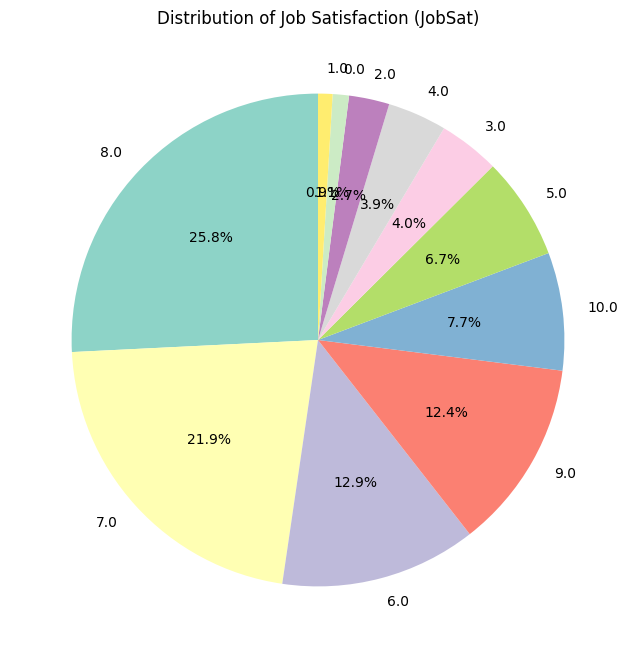

In [6]:
## Write your code here
# Option 1: Pie Chart 
# (Best if JobSat contains categorical text like "Very satisfied", "Slightly dissatisfied")
# ---------------------------------------------------------
plt.figure(figsize=(8, 8))
job_sat_counts = df['JobSat'].value_counts(dropna=True)
job_sat_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90, cmap='Set3')

plt.title('Distribution of Job Satisfaction (JobSat)')
plt.ylabel('') # Hides the default y-label for a cleaner look
plt.show()

### Step 6: Programming Languages Analysis


- Compare the frequency of programming languages in `LanguageHaveWorkedWith` and `LanguageWantToWorkWith`.
  
- Visualize the overlap or differences using a Venn diagram or a grouped bar chart.


  Installing build dependencies ... one
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for matplotlib-venn: filename=matplotlib_venn-1.1.2-py3-none-any.whl size=45388 sha256=3116f1f136da0e79437f8351d0abc2403e2a3112f574bea90858312850d49f9f
  Stored in directory: /home/jupyterlab/.cache/pip/wheels/c2/47/0c/f014c55a1cfd56dce41a1cafd23e3c590652b5e71330cc181c
Successfully built matplotlib-venn


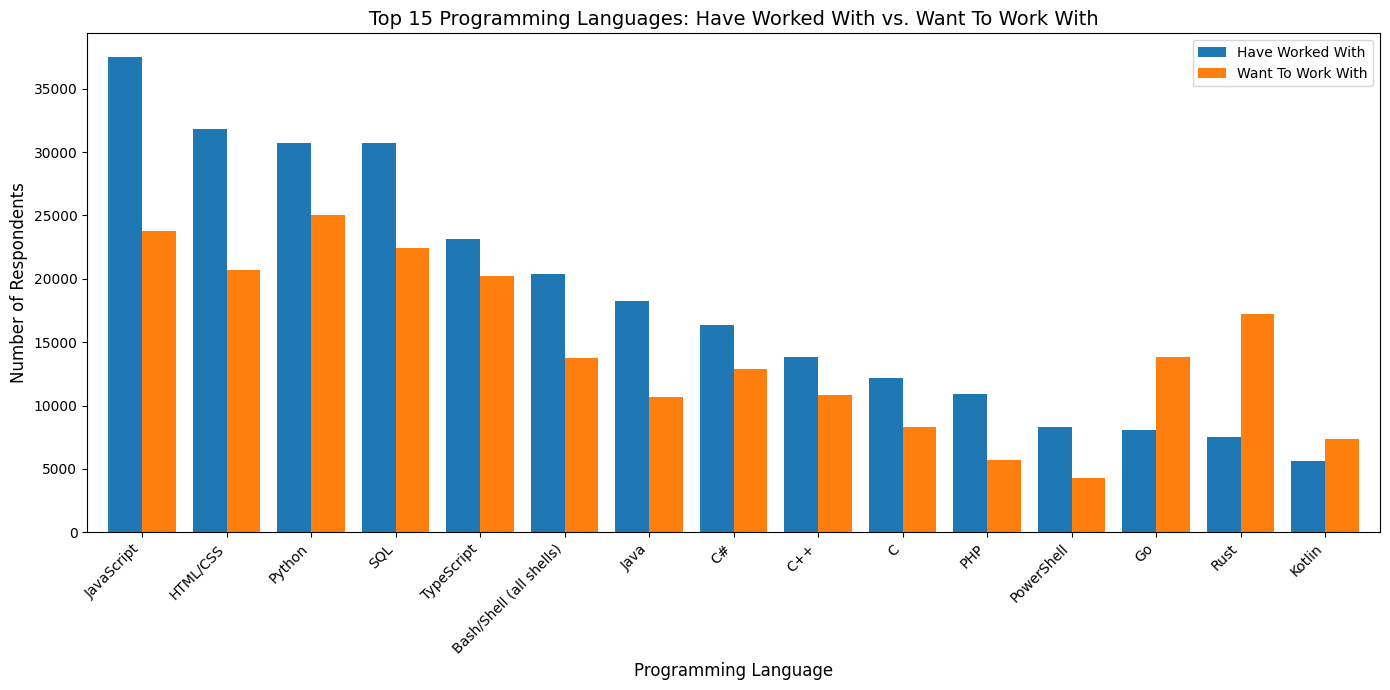

In [7]:
## Write your code here
!pip install matplotlib-venn


import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
# You may need to install the venn library first: pip install matplotlib-venn
from matplotlib_venn import venn2

# Assuming your dataset is loaded into a pandas DataFrame named 'df'
# df = pd.read_csv('developer_survey_data.csv')

# 1. Helper function to count individual languages from semicolon-separated strings
def count_languages(column_data):
    lang_counter = Counter()
    for row in column_data.dropna():
        # Split by semicolon (adjust if your data uses a different separator like commas)
        languages = row.split(';')
        for lang in languages:
            lang_counter[lang.strip()] += 1
    return lang_counter

# Count frequencies for both columns
worked_counts = count_languages(df['LanguageHaveWorkedWith'])
want_counts = count_languages(df['LanguageWantToWorkWith'])

# Convert the counts into a combined pandas DataFrame
df_worked = pd.DataFrame.from_dict(worked_counts, orient='index', columns=['Have Worked With'])
df_want = pd.DataFrame.from_dict(want_counts, orient='index', columns=['Want To Work With'])

# Merge and replace any missing NaN values with 0
df_merged = df_worked.merge(df_want, left_index=True, right_index=True, how='outer').fillna(0)

# Sort by the most popular languages currently worked with and take the top 15 for readability
df_merged = df_merged.sort_values(by='Have Worked With', ascending=False).head(15)

# ---------------------------------------------------------
# Visualization 1: Grouped Bar Chart (Frequencies)
# ---------------------------------------------------------
df_merged.plot(kind='bar', figsize=(14, 7), width=0.8, color=['#1f77b4', '#ff7f0e'])

plt.title('Top 15 Programming Languages: Have Worked With vs. Want To Work With', fontsize=14)
plt.xlabel('Programming Language', fontsize=12)
plt.ylabel('Number of Respondents', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

### Step 7: Analyze Remote Work Trends


- Visualize the distribution of RemoteWork by region using a grouped bar chart or heatmap.


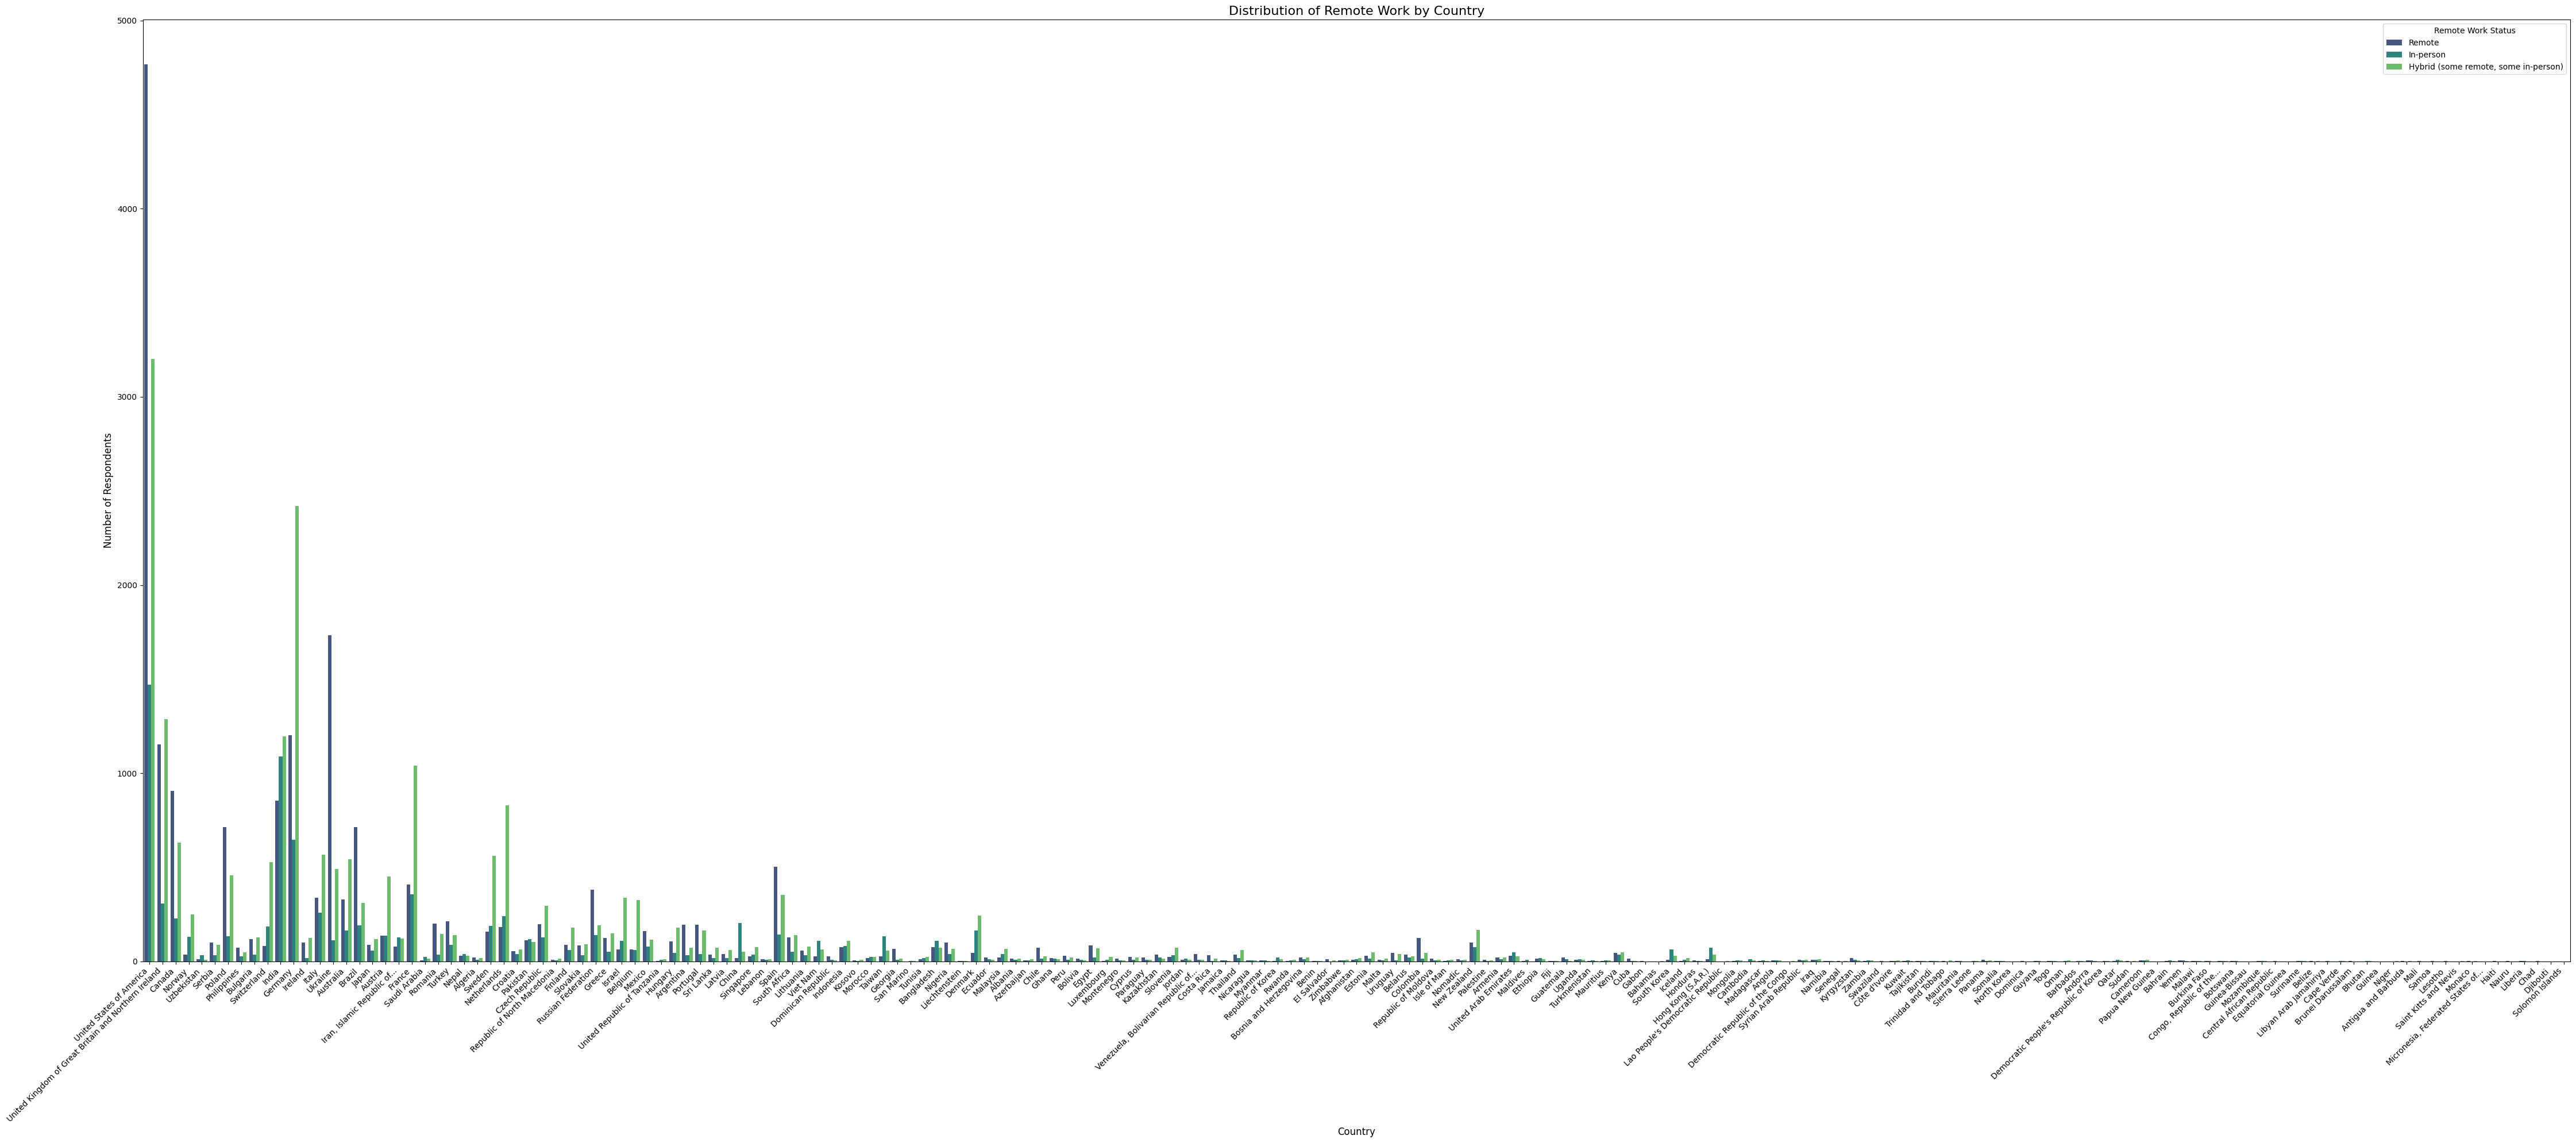

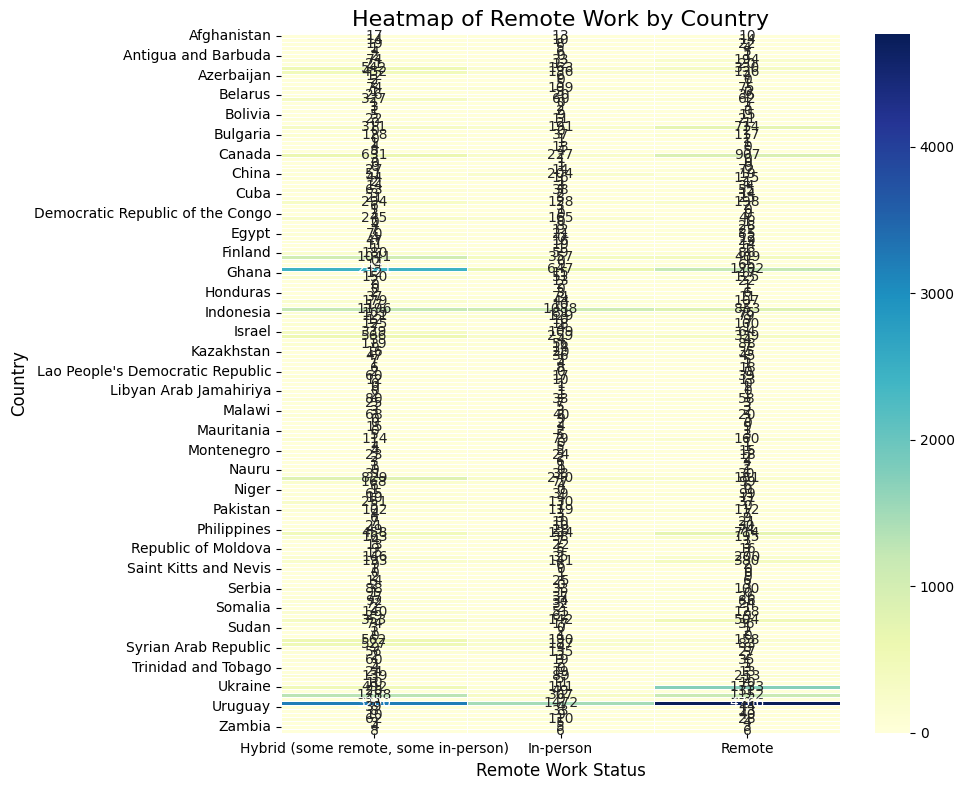

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create a cross-tabulation using 'Country' instead of 'Region'
remote_by_country = pd.crosstab(df['Country'], df['RemoteWork'])

# ---------------------------------------------------------
# Visualization 1: Grouped Bar Chart
# ---------------------------------------------------------
plt.figure(figsize=(45, 20))
# Update the x parameter to 'Country'
sns.countplot(data=df, x='Country', hue='RemoteWork', palette='viridis')

plt.title('Distribution of Remote Work by Country', fontsize=16)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Number of Respondents', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Remote Work Status')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Visualization 2: Heatmap
# ---------------------------------------------------------
plt.figure(figsize=(10, 8))
# Use the updated cross-tabulated data
sns.heatmap(remote_by_country, annot=True, fmt='d', cmap='YlGnBu', linewidths=.5)

plt.title('Heatmap of Remote Work by Country', fontsize=16)
plt.xlabel('Remote Work Status', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.tight_layout()
plt.show()

### Step 8: Correlation between Job Satisfaction and Experience


- Analyze the correlation between overall job satisfaction (`JobSat`) and `YearsCodePro`.
  
- Calculate the Pearson or Spearman correlation coefficient.


In [10]:
## Write your code here
import pandas as pd

# Assuming your dataset is loaded into a pandas DataFrame named 'df'
# df = pd.read_csv('developer_survey_data.csv')

# 1. Data Cleaning (Crucial Step)
# Correlation functions require numeric data. 
# Datasets like the Stack Overflow survey often contain strings in these columns 
# (e.g., "Less than 1 year" or "More than 50 years" in YearsCodePro).
# You must convert these to numeric values first. 
# Here is a basic example of forcing conversion (non-numeric text becomes NaN):

df['YearsCodePro_Num'] = pd.to_numeric(df['YearsCodePro'], errors='coerce')
# If JobSat is categorical (e.g., "Very satisfied"), you must map it to numbers first (e.g., 1-5).
# Assuming JobSat is already a numeric scale for this calculation:
df['JobSat_Num'] = pd.to_numeric(df['JobSat'], errors='coerce')

# 2. Calculate Pearson Correlation (Measures linear relationships)
pearson_corr = df['JobSat_Num'].corr(df['YearsCodePro_Num'], method='pearson')
print(f"Pearson Correlation Coefficient: {pearson_corr:.4f}")

# 3. Calculate Spearman Correlation (Measures monotonic relationships, often better for ordinal rankings)
spearman_corr = df['JobSat_Num'].corr(df['YearsCodePro_Num'], method='spearman')
print(f"Spearman Correlation Coefficient: {spearman_corr:.4f}")

Pearson Correlation Coefficient: 0.1034
Spearman Correlation Coefficient: 0.1207


### Step 9: Cross-tabulation Analysis (Employment vs. Education Level)


- Analyze the relationship between employment status (`Employment`) and education level (`EdLevel`).

- **Instruction**: Create a cross-tabulation using `pd.crosstab()` and visualize it with a stacked bar plot if possible.


Cross-Tabulation of Education Level and Employment:
Employment                                          Employed, full-time  \
EdLevel                                                                   
Associate degree (A.A., A.S., etc.)                                1059   
Bachelor’s degree (B.A., B.S., B.Eng., etc.)                      16806   
Master’s degree (M.A., M.S., M.Eng., MBA, etc.)                   11011   
Primary/elementary school                                           160   
Professional degree (JD, MD, Ph.D, Ed.D, etc.)                     2073   
Secondary school (e.g. American high school, Ge...                 1460   
Some college/university study without earning a...                 3579   
Something else                                                      377   

Employment                                          Employed, full-time;Employed, part-time  \
EdLevel                                                                                       
Associa

/tmp/ipykernel_902/4148525046.py:32: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


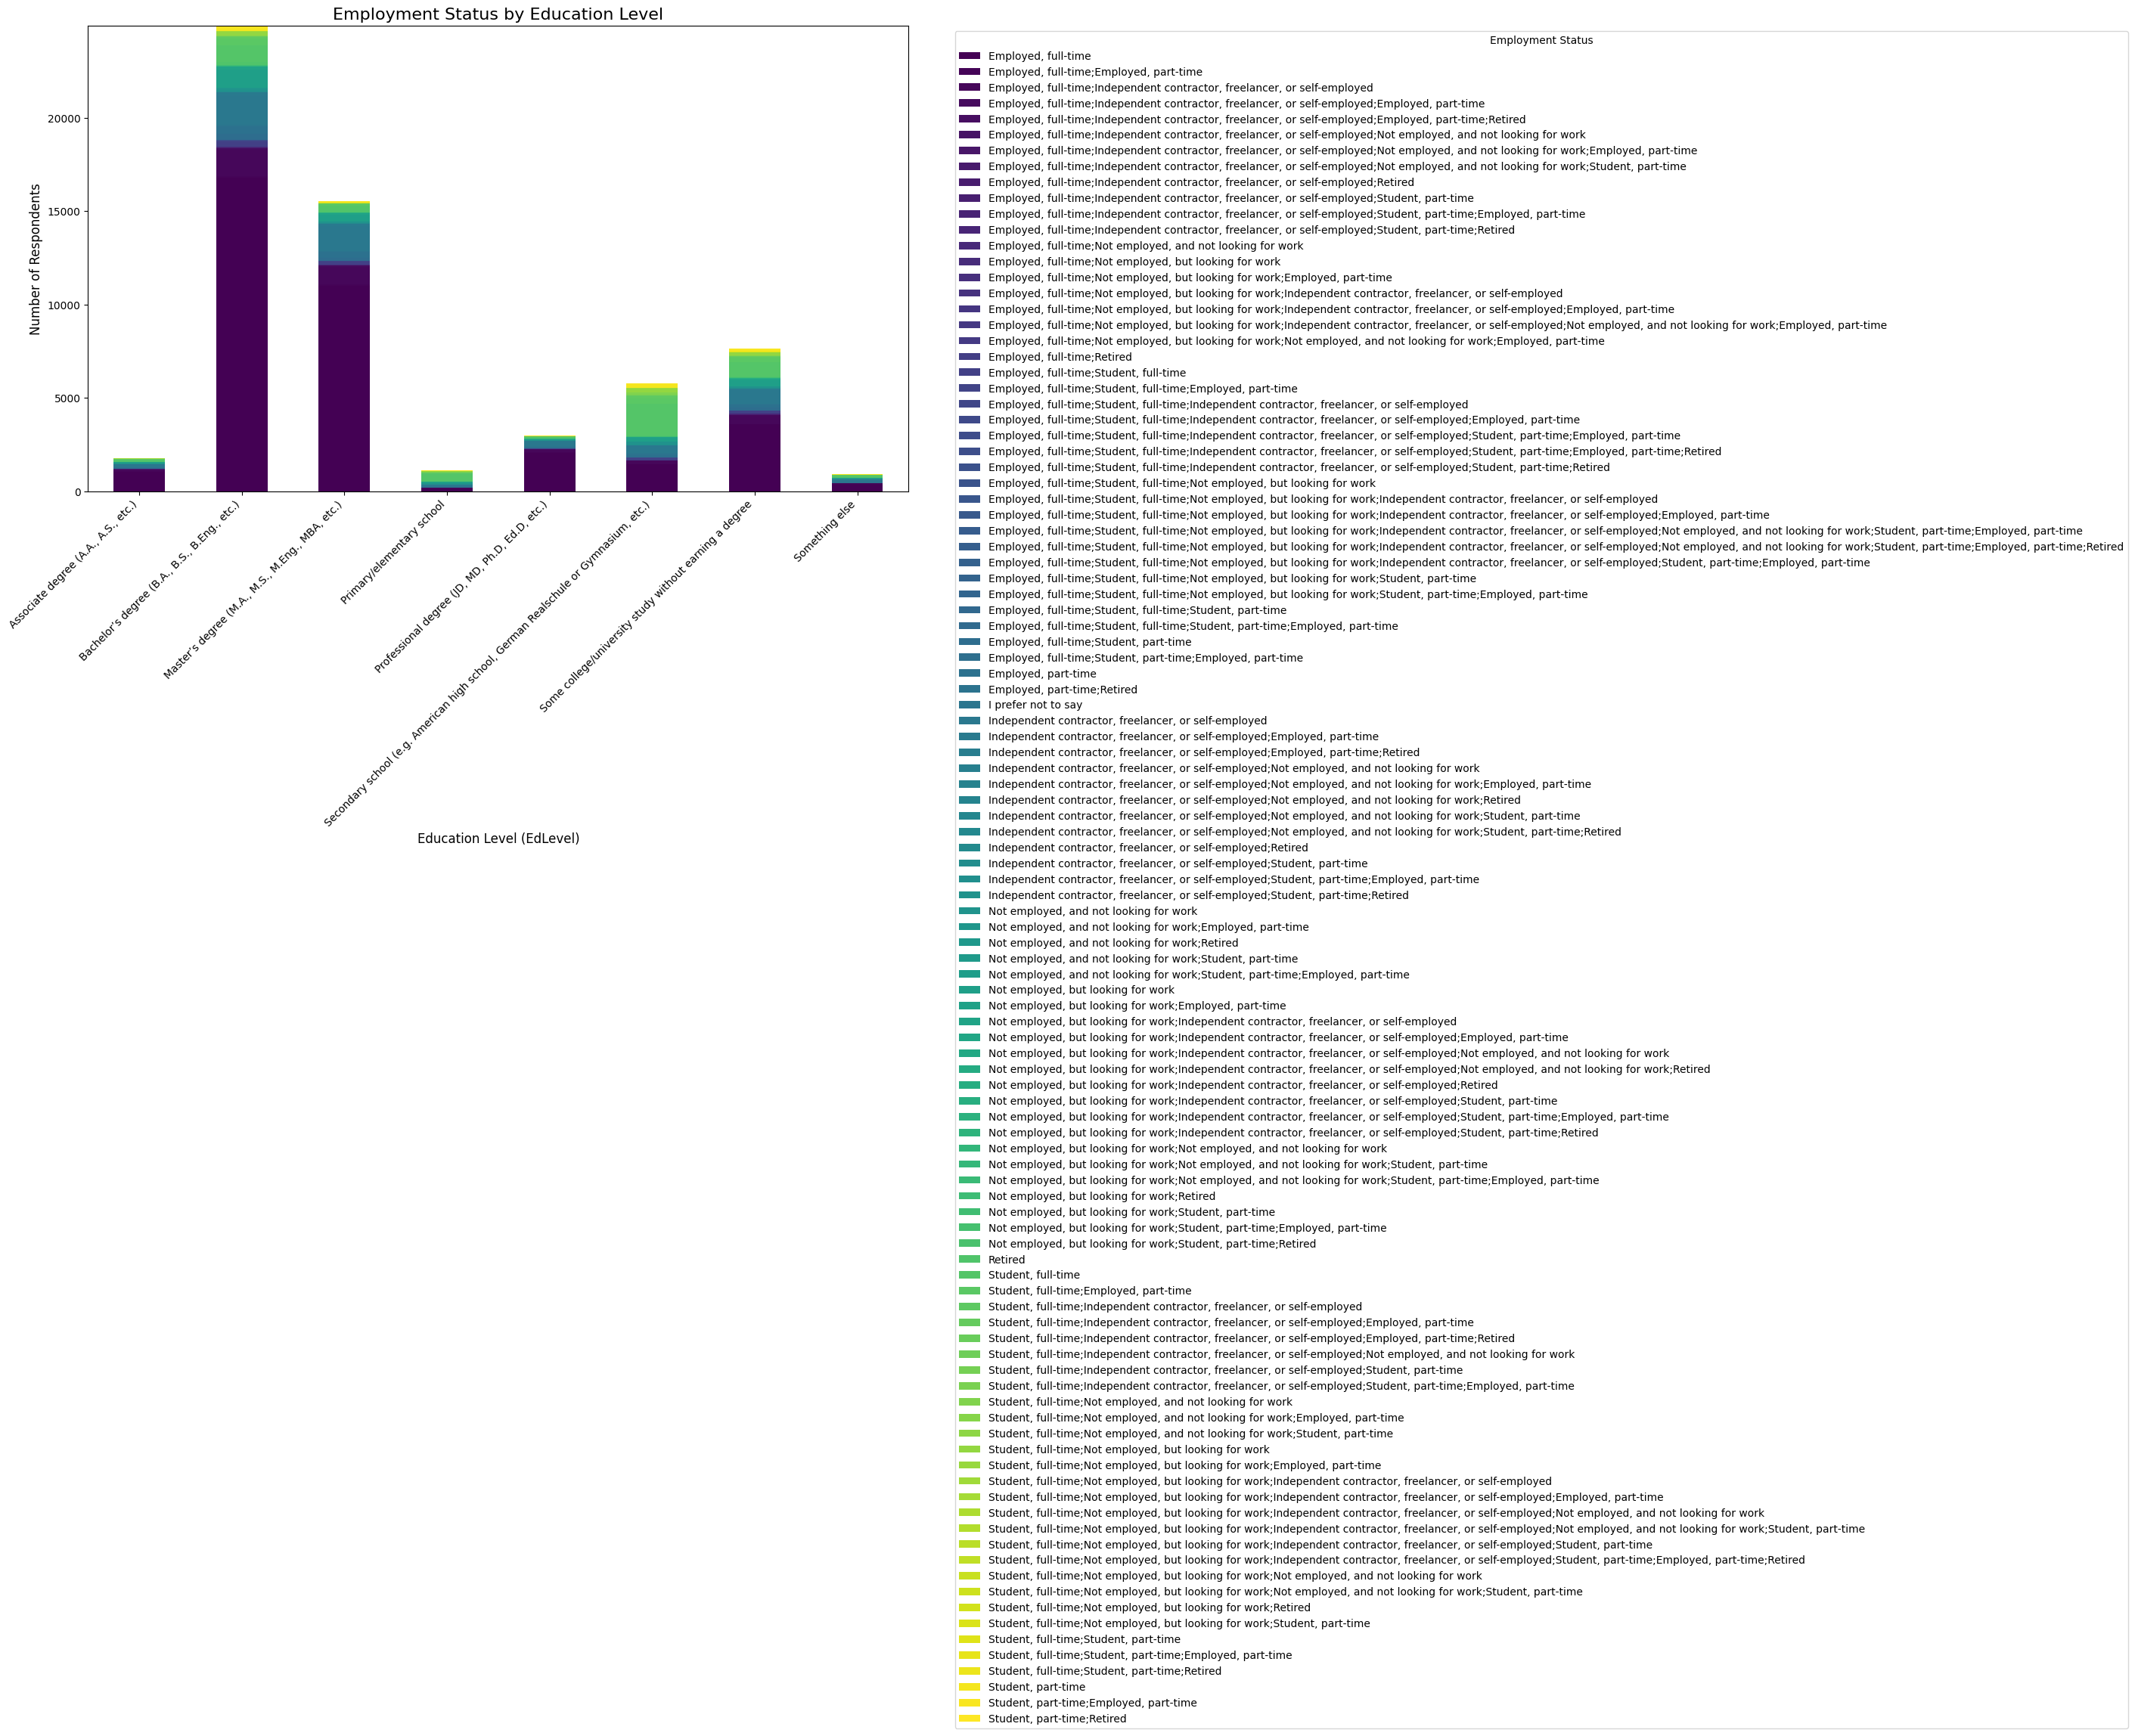

In [11]:
## Write your code here
import pandas as pd
import matplotlib.pyplot as plt

# Assuming your dataset is loaded into a pandas DataFrame named 'df'
# df = pd.read_csv('developer_survey_data.csv')

# 1. Create a cross-tabulation of Education Level and Employment Status
# This calculates the frequency of each employment status within each education level
ed_emp_crosstab = pd.crosstab(df['EdLevel'], df['Employment'])

# Print the table to view the raw numbers
print("Cross-Tabulation of Education Level and Employment:")
print(ed_emp_crosstab)
print("-" * 40)

# 2. Visualize the cross-tabulation as a stacked bar plot
# figsize adjusts the dimensions, and colormap applies a distinct color palette
ed_emp_crosstab.plot(kind='bar', stacked=True, figsize=(14, 8), colormap='viridis')

plt.title('Employment Status by Education Level', fontsize=16)
plt.xlabel('Education Level (EdLevel)', fontsize=12)
plt.ylabel('Number of Respondents', fontsize=12)

# Rotate x-axis labels if education level descriptions are long strings
plt.xticks(rotation=45, ha='right')

# Place the legend outside the plot area so it doesn't cover the data
plt.legend(title='Employment Status', bbox_to_anchor=(1.05, 1), loc='upper left')

# Adjust layout so everything fits without being cut off
plt.tight_layout()
plt.show()

### Step 10: Export Cleaned Data


- Save the cleaned dataset to a new CSV file for further use or sharing.


In [12]:
## Write your code here
import pandas as pd

# Assuming your cleaned dataset is stored in a pandas DataFrame named 'df'
# Specify the desired name for your new file
output_filename = 'cleaned_developer_survey_data.csv'

# Save the DataFrame to a CSV file
df.to_csv(output_filename, index=False)

print(f"Cleaned dataset successfully saved to {output_filename}")

Cleaned dataset successfully saved to cleaned_developer_survey_data.csv


### Summary:


In this lab, you practiced key skills in exploratory data analysis, including:


- Examining the structure and content of the Stack Overflow survey dataset to understand its variables and data types.

- Identifying and addressing missing data to ensure the dataset's quality and completeness.

- Summarizing and visualizing key variables such as job satisfaction, programming languages, and remote work trends.

- Analyzing relationships in the data using techniques like:
    - Comparing programming languages respondents have worked with versus those they want to work with.
      
    - Exploring remote work preferences by region.

- Investigating correlations between professional coding experience and job satisfaction.

- Performing cross-tabulations to analyze relationships between employment status and education levels.


## Authors:
Ayushi Jain


### Other Contributors:
Rav Ahuja
Lakshmi Holla
Malika


Copyright © IBM Corporation. All rights reserved.
